In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess

### Used-Car Depreciation Analysis (Age & Mileage Based)

In [2]:
df_cars=pd.read_csv("cleaned_data.csv")

In [3]:
pd.options.display.float_format = "{:.3f}".format

In [4]:
df_cars

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,vehicle_age
0,2014,Bmw,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,California,45.000,1331.000,gray,black,financial services remarketing (lease),31900.000,30000.000,2015-01-15,1.124
1,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,California,41.000,14282.000,white,black,volvo na rep/world omni,27500.000,27750.000,2015-01-29,0.163
2,2014,Bmw,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,California,43.000,2641.000,gray,black,financial services remarketing (lease),66000.000,67000.000,2014-12-18,1.049
3,2014,Bmw,M5,Base,Sedan,automatic,wbsfv9c51ed593089,California,34.000,14943.000,black,black,the hertz corporation,69000.000,65000.000,2014-12-17,1.047
4,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,California,2.000,28617.000,black,black,enterprise vehicle exchange / tra / rental / t...,11900.000,9800.000,2014-12-16,1.044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558593,2015,Kia,K900,Luxury,Sedan,NaN,knalw4d4xf6019304,Indiana,45.000,18255.000,silver,black,avis corporation,35300.000,33000.000,2015-07-09,0.608
558594,2012,Ram,2500,Power Wagon,Crew cab,automatic,3c6td5et6cg112407,Washington,5.000,54393.000,white,black,i -5 uhlmann rv,30200.000,30800.000,2015-07-08,3.605
558595,2012,Bmw,X5,xDrive35d,Suv,automatic,5uxzw0c58cl668465,California,48.000,50561.000,black,black,financial services remarketing (lease),29800.000,34000.000,2015-07-08,3.605
558596,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap0fc216050,Georgia,38.000,16658.000,white,black,enterprise vehicle exchange / tra / rental / t...,15100.000,11100.000,2015-07-09,0.608


In [5]:
plot_df = (
    df_cars
    .groupby(["make", "vehicle_age"], as_index=False)["sellingprice"]
    .mean()
)

In [6]:
top_ten=df_cars["make"].value_counts()[0:10]

In [7]:
t_ten_make=pd.DataFrame(top_ten).reset_index()["make"]

In [8]:
plot_df_filtered = plot_df[plot_df["make"].isin(t_ten_make)]

In [9]:
plot_df_filtered

,make,vehicle_age,sellingprice
2240,Bmw,0.119,39029.412
2241,Bmw,0.124,64000.000
2242,Bmw,0.138,27600.000
2243,Bmw,0.146,30000.000
2244,Bmw,0.157,36305.357
...,...,...,...
40128,Toyota,25.160,375.000
40129,Toyota,25.258,325.000
40130,Toyota,25.264,550.000
40131,Toyota,26.047,800.000


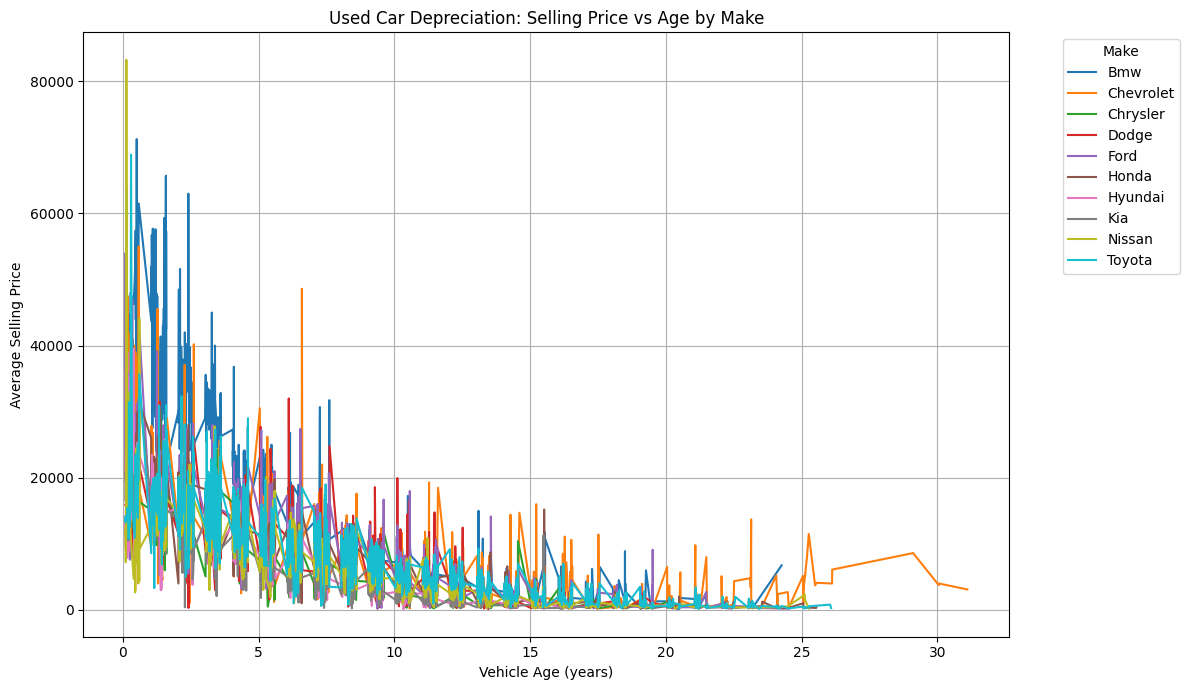

In [10]:
plt.figure(figsize=(12, 7))

for make, grp in plot_df_filtered.groupby("make"):
    plt.plot(
        grp["vehicle_age"],
        grp["sellingprice"],
        label=make
    )

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Average Selling Price")
plt.title("Used Car Depreciation: Selling Price vs Age by Make")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.show()

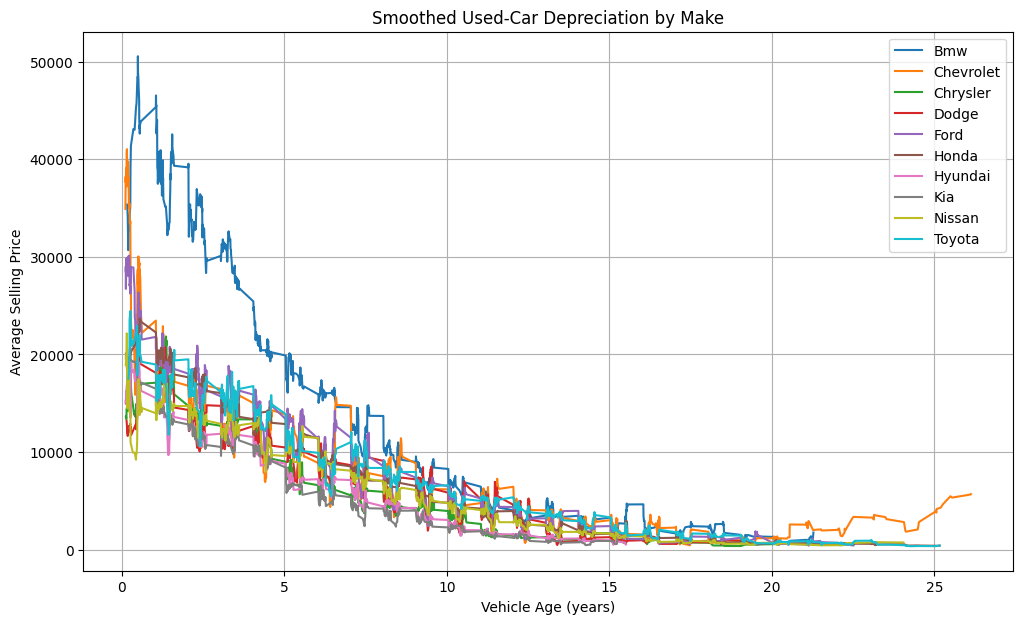

In [11]:
window = 10 

plt.figure(figsize=(12, 7))

for make, grp in plot_df_filtered.groupby("make"):
    grp = grp.sort_values("vehicle_age")
    smoothed = grp["sellingprice"].rolling(window=window, center=True).mean()

    plt.plot(grp["vehicle_age"], smoothed, label=make)

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Average Selling Price")
plt.title("Smoothed Used-Car Depreciation by Make")
plt.legend()
plt.grid(True)
plt.show()

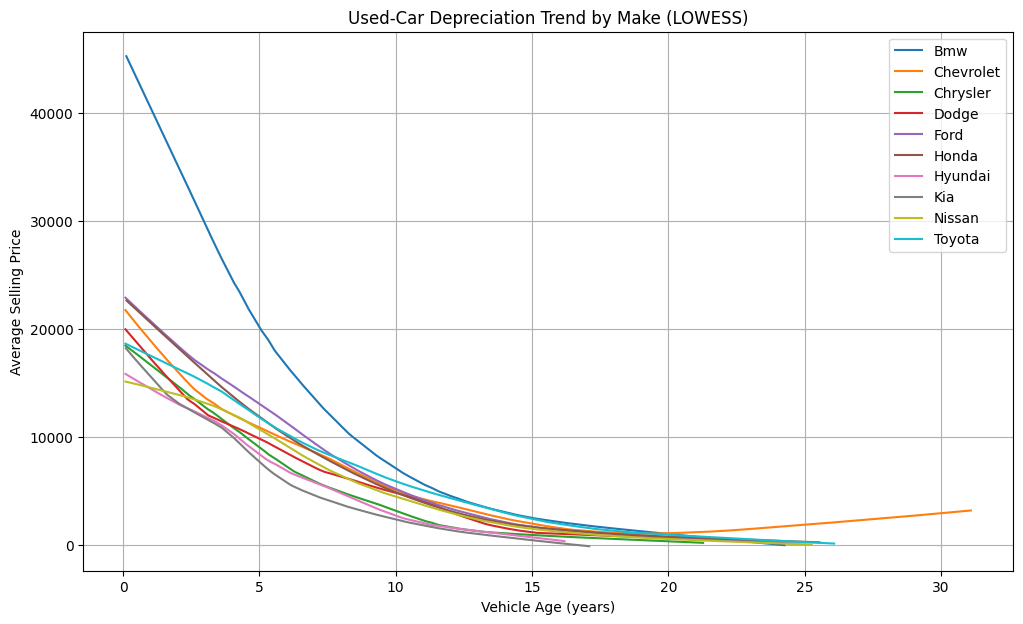

In [12]:
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.figure(figsize=(12, 7))

for make, grp in plot_df_filtered.groupby("make"):
    grp = grp.sort_values("vehicle_age")
    smoothed = lowess(
        grp["sellingprice"],
        grp["vehicle_age"],
        frac=0.3  # smoothing strength (0.2–0.4 works well)
    )

    plt.plot(smoothed[:, 0], smoothed[:, 1], label=make)

plt.xlabel("Vehicle Age (years)")
plt.ylabel("Average Selling Price")
plt.title("Used-Car Depreciation Trend by Make (LOWESS)")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
milage_df=(
    df_cars
    .groupby(["make", "odometer"], as_index=False)["sellingprice"]
    .mean())

In [14]:
top_ten_milage=df_cars["make"].value_counts()[0:10]

In [15]:
t_ten_make_milage=pd.DataFrame(top_ten_milage).reset_index()["make"]
plot_df_milage_filtered = milage_df[milage_df["make"].isin(t_ten_make_milage)]

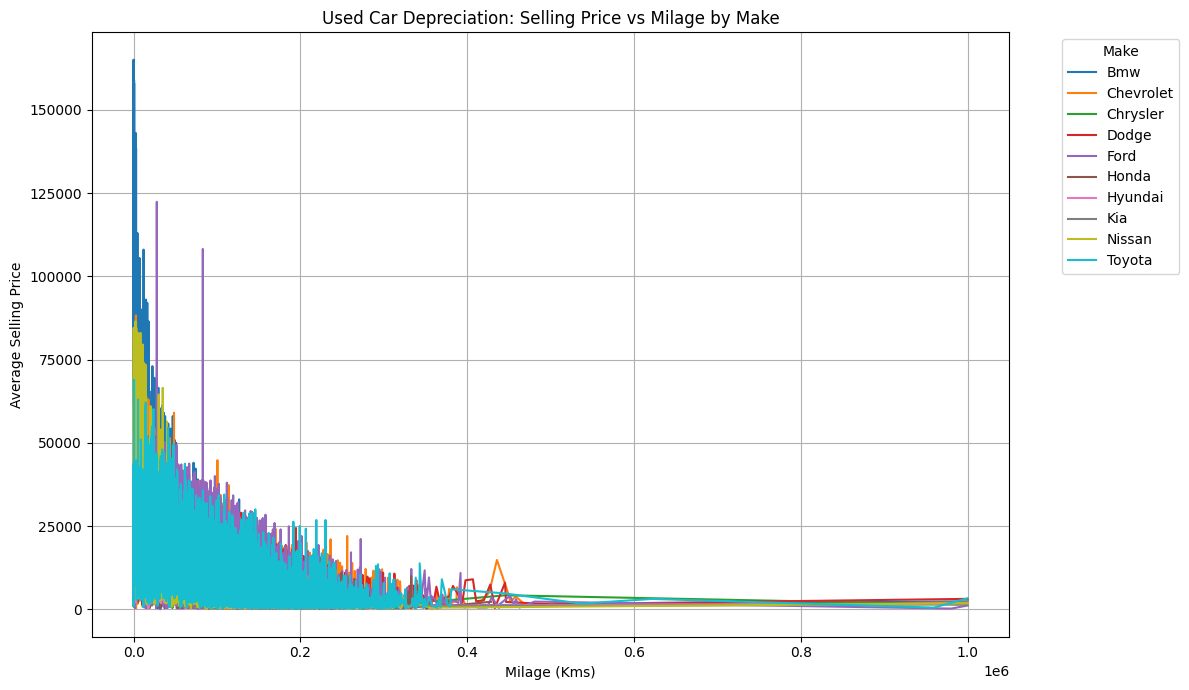

In [16]:
plt.figure(figsize=(12, 7))

for make, grp in plot_df_milage_filtered.groupby("make"):
    plt.plot(
        grp["odometer"],
        grp["sellingprice"],
        label=make
    )

plt.xlabel("Milage (Kms)")
plt.ylabel("Average Selling Price")
plt.title("Used Car Depreciation: Selling Price vs Milage by Make")
plt.legend(title="Make", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.tight_layout()
plt.show()

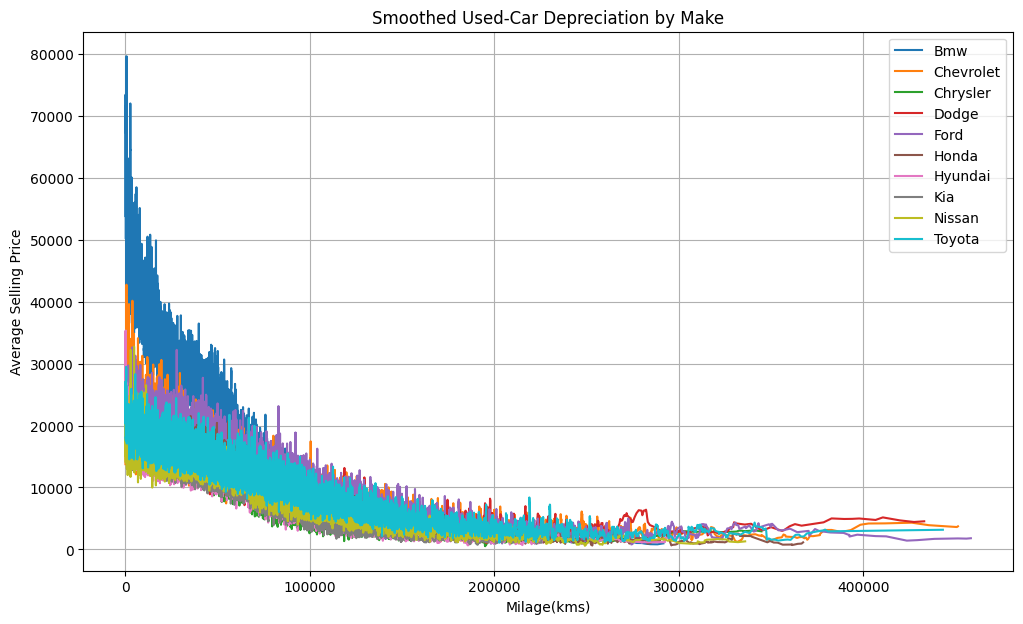

In [21]:
window = 10 

plt.figure(figsize=(12, 7))

for make, grp in plot_df_milage_filtered.groupby("make"):
    grp = grp.sort_values("odometer")
    smoothed = grp["sellingprice"].rolling(window=window, center=True).mean()

    plt.plot(grp["odometer"], smoothed, label=make)

plt.xlabel("Milage(kms)")
plt.ylabel("Average Selling Price")
plt.title("Smoothed Used-Car Depreciation by Make")
plt.legend()
plt.grid(True)
plt.show()